In [1]:
from sbcasdiego.Datasets.DefaultDataset import DefaultDataset
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
aids_clinical_trials_group_study_175 = fetch_ucirepo(id=890) 
  
# data (as pandas dataframes) 
X = aids_clinical_trials_group_study_175.data.features 
y = aids_clinical_trials_group_study_175.data.targets 

In [3]:
# Add a new column 'target' to X safely
X = X.copy()  # Ensure X is a copy, not a view
X['target'] = y['cid']  # Explicitly reference the column in y
target = 'target'
print(X.size)


51336


In [4]:
df = X
df = df.dropna()
df = df.drop_duplicates()
print(df.size)

51336


In [5]:
df.head(2)

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,target
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1


In [6]:
h = DefaultDataset(
    dataset= df,
    predicted_attr=target,
    protected_attr=None,
    protected_attr_mappings=None,
    positive_outcome=1
)
# h.num_repetitions = 1
# h.execute_models()

Max correlation: time (-0.5749887162094113)


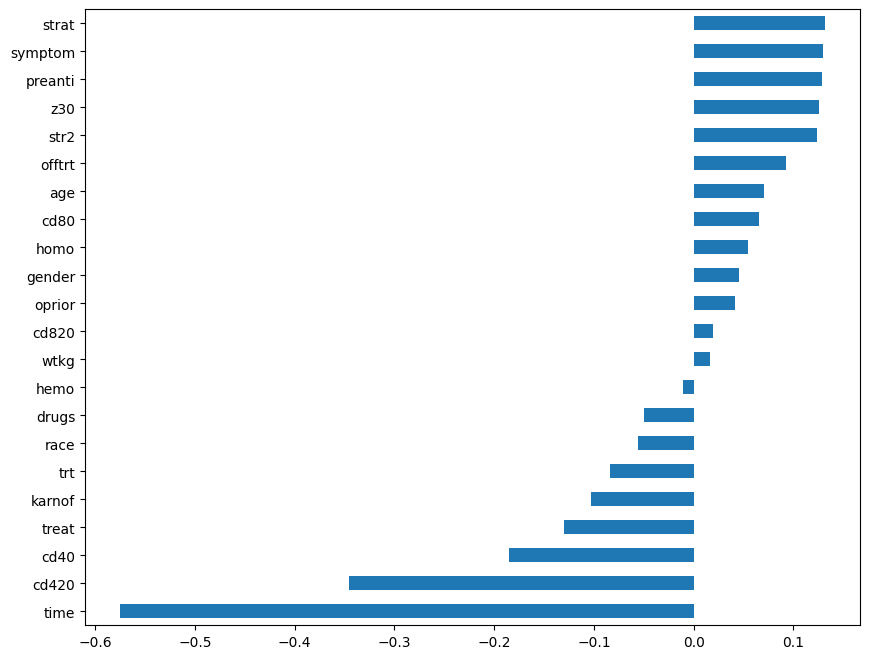

In [7]:
correlations = df.corr()[target].drop(target).dropna().sort_values()
correlations.plot(kind='barh', figsize=(10, 8))

max_corr = correlations.abs().idxmax()
print(f"Max correlation: {max_corr} ({correlations[max_corr]})")


In [8]:
protected_attr_mappings = {}
for column in df.columns:
    if df[column].nunique() == 2 and column != h.predicted_attr:
        protected_attr_mappings[column] = {"Privileged": df[column].value_counts().idxmax(), "Unprivileged": df[column].value_counts().idxmin()}
protected_attr_mappings

{'hemo': {'Privileged': 0, 'Unprivileged': 1},
 'homo': {'Privileged': 1, 'Unprivileged': 0},
 'drugs': {'Privileged': 0, 'Unprivileged': 1},
 'oprior': {'Privileged': 0, 'Unprivileged': 1},
 'z30': {'Privileged': 1, 'Unprivileged': 0},
 'race': {'Privileged': 0, 'Unprivileged': 1},
 'gender': {'Privileged': 1, 'Unprivileged': 0},
 'str2': {'Privileged': 1, 'Unprivileged': 0},
 'symptom': {'Privileged': 0, 'Unprivileged': 1},
 'treat': {'Privileged': 1, 'Unprivileged': 0},
 'offtrt': {'Privileged': 0, 'Unprivileged': 1}}

In [9]:
h.protected_attr_mappings = protected_attr_mappings
h.protected_attr = list(protected_attr_mappings.keys())
h.get_metrics(correlated_vars=max_corr,
    df_train=df)

{'Class Imbalance': {'hemo': -0.8316970546984572,
  'homo': 0.32211313697989713,
  'drugs': -0.737260402057036,
  'oprior': -0.9560542309490416,
  'z30': 0.1005142589995325,
  'race': -0.4230949041608228,
  'gender': 0.6559139784946236,
  'str2': 0.171575502571295,
  'symptom': -0.654043945769051,
  'treat': 0.5025712949976625,
  'offtrt': -0.27442730247779334},
 'KS': {'hemo': 0.017245193125744462,
  'homo': 0.04922011412963956,
  'drugs': 0.0632716463192734,
  'oprior': 0.12078434563280585,
  'z30': 0.10827679519268307,
  'race': 0.05303522406114958,
  'gender': 0.05131281761716544,
  'str2': 0.10752163205597765,
  'symptom': 0.1466624906421402,
  'treat': 0.1286512017442486,
  'offtrt': 0.08289211941517727},
 'KL Divergence': {'hemo': 0.0008171107391204586,
  'homo': 0.006907629804163672,
  'drugs': 0.011314051391637783,
  'oprior': 0.03636295724910897,
  'z30': 0.0345041999417811,
  'race': 0.007701035476163694,
  'gender': 0.007736121558064302,
  'str2': 0.03444603377478181,
  'sy